<a href="https://colab.research.google.com/github/Ibrah-N/PNID_Custom_OCR/blob/main/PNID_OCR_Data_Preparation_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# script for installing label-studio
python3 -m venv lbl_en
source lbl_env/bin/activate # mac
pip install label-studio

# script for running label-studio
source lbl_env/bin/activate # mac
label-studio

# Helpers

In [48]:
import math
import numpy as np


def xywhrot_xyxyxyxy(label, percentages=True):
  """
  Converting Label Studio format into Oriented Bounding Box (OBB) format.

  Args:
    label (dict): Dictionary containing annotation information
    percentages (bool): if true it will convert percenatage values into pixels values

  Maths:
    label:
      x, y, width, height, rotation

      if percentages:
        x = x / 100 * original_width
        y = y / 100 * original_height
        w = width / 100 * original_width
        h = height / 100 * original_height

      rotation:
        rotation_ = math.radians(rotation)
        cos, sin = math.cos(rotation_), math.sin(rotation_)

        coords = [
          (x, y),
          (x + w * cos, y + w * sin),
          (x + w * cos - h * sin, y + w * sin + h * cos),
          (x - h * sin, y + h * cos),
        ]

  Returns:
    list of tuple or None: List of tuples containing the coordinates of the object in Yolo OBB
  """

  # unpick values
  original_width = label['original_width']
  original_height = label['original_height']
  x, y = label['x'], label['y']
  w, h = label['width'], label['height']
  rotation = label['rotation']


  if percentages:
    x = x / 100 * original_width
    y = y / 100 * original_height
    w = w / 100 * original_width
    h = h / 100 * original_height

  # rotation -> angles
  rotation = math.radians(rotation)
  cos, sin = math.cos(rotation), math.sin(rotation)

  # xywhr -> xyxyxyxy
  coords = [
      (x, y),
      (x + w * cos, y + w * sin),
      (x + w * cos -h * sin, y + w * sin + h * cos),
      (x - h * sin, y + h * cos)
  ]

  return np.array(coords, dtype=np.int32)


def xyxyxyxy_xywhr(xyxyxyxy, original_width, original_height):
  """
    Convert YOLO Oriented Bounding Box (OBB) format to Label Studio format.

    Args:
        xyxyxyxy (list): List of 8 float values representing the absolute pixel coordinates
                         of the OBB in the format [x1, y1, x2, y2, x3, y3, x4, y4]
        original_width (int): Original width of the image
        original_height (int): Original height of the image


    Return:
        dict: Dictionary containing the converted bounding box
              list: [x, y, width, height, rotation, original_width, original_height]
  """
  # Reshape the coordinates into a 4x2 matrix
  coords = np.array(xyxyxyxy, dtype=np.float64).reshape((4, 2))

  # Calculate the center of the bounding box
  center_x = np.mean(coords[:, 0])
  center_y = np.mean(coords[:, 1])

  # Calculate the width and height of the bounding box
  width = np.linalg.norm(coords[0] - coords[1])
  height = np.linalg.norm(coords[0] - coords[3])

  # Calculate the rotation angle
  dx = coords[1, 0] - coords[0, 0]
  dy = coords[1, 1] - coords[0, 1]
  r = np.degrees(np.arctan2(dy, dx))

  # Find the top-left corner (x, y)
  top_left_x = (
      center_x
      - (width / 2) * np.cos(np.radians(r))
      + (height / 2) * np.sin(np.radians(r))
  )
  top_left_y = (
      center_y
      - (width / 2) * np.sin(np.radians(r))
      - (height / 2) * np.cos(np.radians(r))
  )

  # Normalize the values
  x = (top_left_x / original_width) * 100
  y = (top_left_y / original_height) * 100
  width = (width / original_width) * 100
  height = (height / original_height) * 100

  # Create the dictionary for Label Studio
  return {
      "x": x,
      "y": y,
      "width": width,
      "height": height,
      "rotation": r,
      "original_width": original_width,
      "original_height": original_height,
  }

# Load Data

In [29]:
!unzip /content/project-2-at-2026-03-08-09-36-de99cbc3.zip -d /content/data_01


Archive:  /content/project-2-at-2026-03-08-09-36-de99cbc3.zip
replace /content/data_01/classes.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [49]:
#====================================#
#   D A T A - L O A D - C L A S S    #
#====================================#

import os
import json

class LoadData:

  def __init__(self, json_path, image_dir_path, txt_annot_path):
    self.json_path = json_path
    self.image_dir_path = image_dir_path
    self.txt_annot_path = txt_annot_path


  def load_json(self):

    if os.path.exists(self.json_path) and self.json_path.lower().endswith(".json"):
      with open(self.json_path, "r") as f:
        jsons_list = json.load(f)
    else:
      raise ValueError(f"Invalid json path: {self.json_path}")

    return jsons_list


  def load_image(self):
    images_list = os.listdir(self.image_dir_path)
    images_list = [os.path.join(self.image_dir_path, image_) for image_ in images_list\
                   if image_.lower().endswith(".jpg") or image_.lower().endswith(".png")]
    return images_list


  def load_txt_annot(self):
    txt_annot_list = os.listdir(self.txt_annot_path)
    txt_annot_list = [os.path.join(self.txt_annot_path, annot_) for annot_ in txt_annot_list\
                      if annot_.lower().endswith(".txt")]
    return txt_annot_list


In [50]:
JSON_PATH = "/content/project-2-at-2026-03-08-09-35-de99cbc3.json"
IMAGES_PATH = "/content/data_01/images"
TXT_PATH = "/content/data_01/labels"


dala_cls = LoadData(json_path=JSON_PATH, image_dir_path=IMAGES_PATH, txt_annot_path=TXT_PATH)

In [51]:
json_list = dala_cls.load_json()

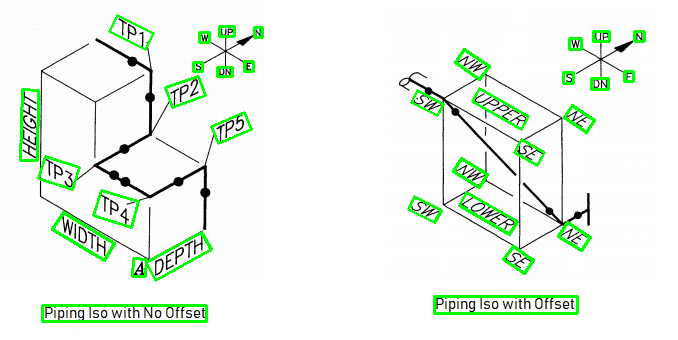

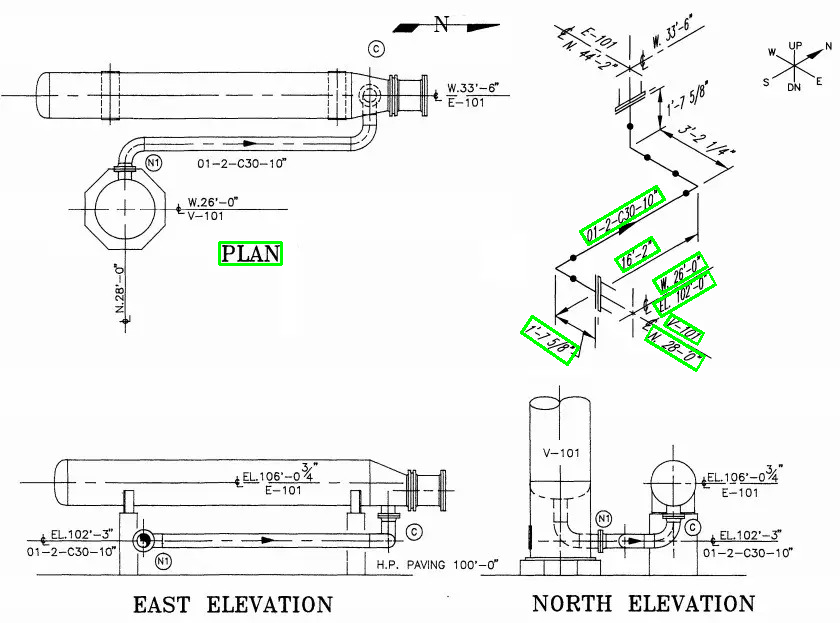

In [56]:
import cv2
from google.colab.patches import cv2_imshow
import os # Ensure os module is imported for os.path.basename

for json in json_list:

  image_name = json['ocr']
  obboxes = json['bbox'] # list (x, y, width, height, rotation)
  transcription = json['transcription'] # list()

  # Correctly extract the filename and construct the image path
  image_filename = os.path.basename(image_name)
  image_path = os.path.join(IMAGES_PATH, image_filename)
  image = cv2.imread(image_path)

  # Check if the image was loaded successfully
  if image is None:
    print(f"Warning: Could not load image from {image_path}. Skipping.")
    continue # Skip to the next item in json_list

  for item in obboxes:
    obb = xywhrot_xyxyxyxy(item)
    cv2.polylines(image, [obb], True, (0, 255, 0), 2)


  cv2_imshow(image)
  # break